In [1]:
import os
os.chdir('..')
if os.path.exists('Groenbeeld'):
  !rm -rf Groenbeeld

In [2]:
import sys
!{sys.executable} -m pip install owslib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.5/240.5 kB 3.6 MB/s eta 0:00:00


In [3]:
import os

!git clone https://github.com/bart314/Groenbeeld.git
os.chdir('Groenbeeld')
!git checkout clustering
!ls

Cloning into 'Groenbeeld'...
remote: Enumerating objects: 223, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 223 (delta 43), reused 40 (delta 15), pack-reused 139 (from 1)
Receiving objects: 100% (223/223), 11.34 MiB | 21.26 MiB/s, done.
Resolving deltas: 100% (107/107), done.
Branch 'clustering' set up to track remote branch 'clustering' from 'origin'.
Switched to a new branch 'clustering'
Data	    NDVI-SWF.yaml  README.md  targets.txt
LICENSE.md  outdir	   Scripts    Tutorial_grondwaterstand


In [4]:
import os

# Define the expected output path for the CIR data from the previous script.
# This assumes 'outdir/municipality_survey_V2/BU19000102_Stationsbuurt_CIR.tif'
# is a reliable indicator that the script has already run successfully.
output_dir = 'outdir/municipality_survey_V2'
target_id_prefix = 'BU19000102_Stationsbuurt' # Based on previous script output and subsequent cell usage
expected_output_file = os.path.join(output_dir, f"{target_id_prefix}_CIR.tif")

# Ensure the output directory structure is created for the check
os.makedirs(output_dir, exist_ok=True)

if os.path.exists(expected_output_file):
    print(f"Detected existing output file: {expected_output_file}. Skipping `Municipality_Surveyor_V2.py` execution.")
else:
    print(f"Output file {expected_output_file} not found. Running `Municipality_Surveyor_V2.py` to generate data...")
    !python3 "Scripts/Municipality_Surveyor_V2.py"

Output file outdir/municipality_survey_V2/BU19000102_Stationsbuurt_CIR.tif not found. Running `Municipality_Surveyor_V2.py` to generate data...
Loaded 1 targets from targets.txt
Initializing CIR WMTS service...
Initializing RGB WMTS service...
Initiatlizing BRT WMTS service...
Initializing BRT-A Background service...
Initializing BGT WMTS service...
WMTS initialized. Resolution: 0.21m/px
Initializing KEA WMS service...
Connecting to Sogelink Server for ['gevoelstemperatuur_2022', 'RMK_BKB_AHN4', 'RMK_SchaduwGrijs_AHN4', 'RMK_SchaduwGroen_AHN4', 'BGV_ONO_2024', 'BGV_landbedekking_2024', 'RMK_30percBKB_AHN4']...
 SUCCESS: Layer 'gevoelstemperatuur_2022' found.
 SUCCESS: Layer 'RMK_BKB_AHN4' found.
 SUCCESS: Layer 'RMK_SchaduwGrijs_AHN4' found.
 SUCCESS: Layer 'RMK_SchaduwGroen_AHN4' found.
 SUCCESS: Layer 'BGV_ONO_2024' found.
 SUCCESS: Layer 'BGV_landbedekking_2024' found.
 SUCCESS: Layer 'RMK_30percBKB_AHN4' found.
 ERROR: Could not retrieve capabilities.
Fetching all buurten for Súdwe

In [5]:
!python3 "/Groenbeeld/Scripts/Exploratory_Clustering.py"

Loaded 1 targets from targets.txt

Processing Target: BU19000102
Error: Could not find all required TIF files for BU19000102 in outdir/municipality_survey


In [6]:
import sys
!{sys.executable} -m pip install rasterio matplotlib

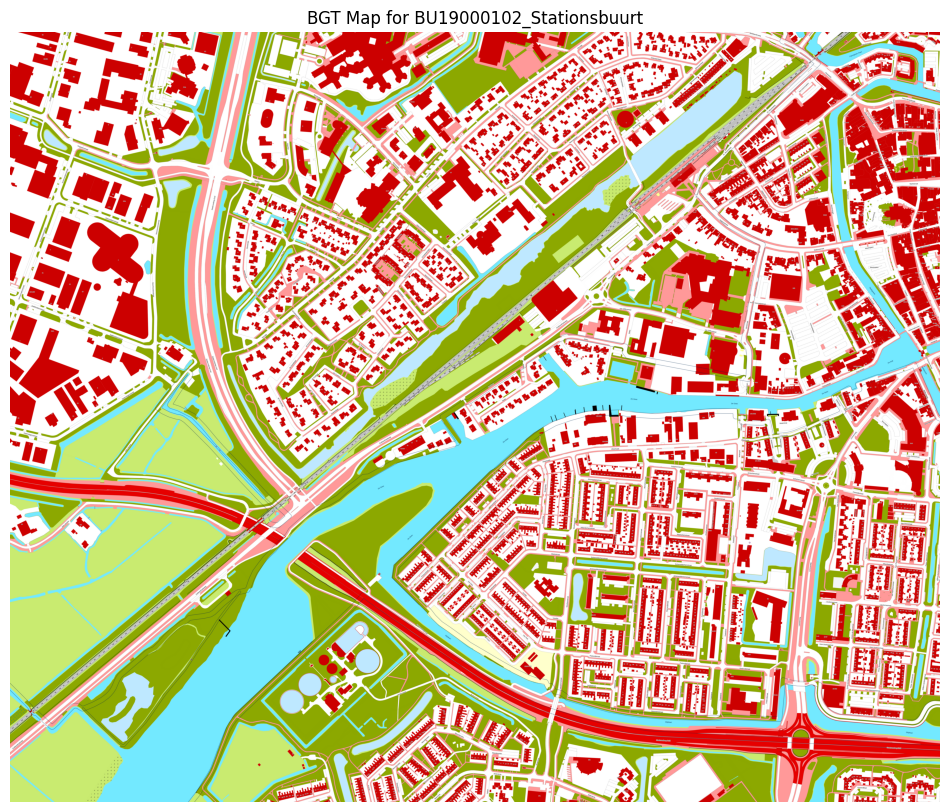

Displayed BGT map from outdir/municipality_survey_V2/BU19000102_Stationsbuurt_BGT.tif

--- Sampled RGB Color Categories from BGT Map ---
Top 10 most frequent RGB colors (out of 67050 unique colors):
  1. RGB: [255 255 255] (Count: 21363064)
  2. RGB: [140 168   0] (Count: 11736711)
  3. RGB: [204   0   0] (Count: 9424934)
  4. RGB: [115 233 255] (Count: 5731876)
  5. RGB: [255 153 153] (Count: 5099519)
  6. RGB: [201 235 112] (Count: 5050150)
  7. RGB: [190 232 255] (Count: 1432232)
  8. RGB: [230   0   0] (Count: 999054)
  9. RGB: [192 192 192] (Count: 318841)
  10. RGB: [255 255 204] (Count: 167196)


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import os
import rasterio

# --- Display the BGT map at the end ---

# Define variables needed to load the BGT map
user_output_dir = 'outdir'
target_id = 'BU19000102'
neighborhood_full_name = f"{target_id}_Stationsbuurt"
bgt_map_path = os.path.join(user_output_dir, 'municipality_survey_V2', f"{neighborhood_full_name}_BGT.tif")

if os.path.exists(bgt_map_path):
    try:
        with rasterio.open(bgt_map_path) as src:
            # Read all bands for RGB image
            bgt_image = src.read()

        # Rasterio reads as (bands, height, width), matplotlib imshow expects (height, width, bands)
        # So, we need to move the band axis to the last position
        bgt_image_display = np.moveaxis(bgt_image, 0, -1)

        plt.figure(figsize=(12, 10))
        # For RGB images, we usually don't use a colormap or vmin/vmax directly
        plt.imshow(bgt_image_display)
        plt.title(f"BGT Map for {neighborhood_full_name}")
        plt.axis('off')
        plt.show()
        plt.close('all')
        print(f"Displayed BGT map from {bgt_map_path}")

        # --- Retrieve Color Categories (RGB values) ---
        # Since it's an RGB image, 'color categories' are essentially the unique or representative RGB triplets.
        # We can sample some pixel values to show this.
        print("\n--- Sampled RGB Color Categories from BGT Map ---")
        # Reshape the image to a list of pixels (height * width, bands)
        pixels = bgt_image_display.reshape(-1, bgt_image_display.shape[-1])

        # Get unique RGB combinations and their counts
        unique_colors, counts = np.unique(pixels, axis=0, return_counts=True)

        # Sort unique colors by frequency (most common first)
        sorted_indices = np.argsort(counts)[::-1]
        top_n_colors = unique_colors[sorted_indices[:10]] # Get top 10 most frequent colors

        print(f"Top {len(top_n_colors)} most frequent RGB colors (out of {len(unique_colors)} unique colors):")
        for i, color in enumerate(top_n_colors):
            print(f"  {i+1}. RGB: {color} (Count: {counts[sorted_indices[i]]})")

    except Exception as e:
        print(f"Error loading or displaying BGT map: {e}")
else:
    print(f"BGT map not found at {bgt_map_path}. Please ensure it was generated and saved correctly.")

In [8]:
if 'top_n_colors' in globals():
    print("Top 10 most frequent RGB colors (from previous cell):")
    for i, color in enumerate(top_n_colors):
        print(f"  {i+1}. RGB: {color}")
else:
    print("The 'top_n_colors' variable was not found. Please ensure the previous cell was executed to retrieve the colors.")

Top 10 most frequent RGB colors (from previous cell):
  1. RGB: [255 255 255]
  2. RGB: [140 168   0]
  3. RGB: [204   0   0]
  4. RGB: [115 233 255]
  5. RGB: [255 153 153]
  6. RGB: [201 235 112]
  7. RGB: [190 232 255]
  8. RGB: [230   0   0]
  9. RGB: [192 192 192]
  10. RGB: [255 255 204]


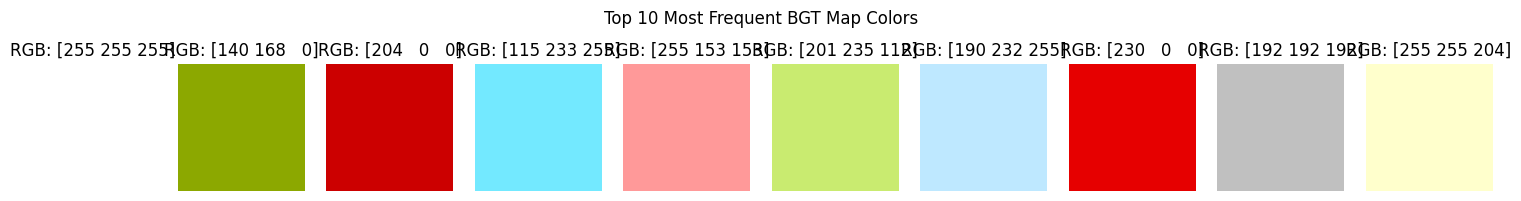

In [9]:
import matplotlib.pyplot as plt
import numpy as np

if 'top_n_colors' in globals() and top_n_colors.size > 0:
    fig, axes = plt.subplots(1, len(top_n_colors), figsize=(len(top_n_colors) * 1.5, 2))
    fig.suptitle('Top 10 Most Frequent BGT Map Colors')

    for i, color_rgb in enumerate(top_n_colors):
        # Normalize RGB values to 0-1 range for matplotlib display if they are not already
        # Assuming colors are in 0-255 range from previous output
        normalized_color = color_rgb / 255.0

        ax = axes[i]
        ax.imshow([[normalized_color]]) # Display a single pixel of this color
        ax.axis('off') # Hide axes
        ax.set_title(f'RGB: {color_rgb}')

    plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()
else:
    print("No 'top_n_colors' found or it is empty. Please ensure the previous cells were executed correctly.")

jenkspy not found, installing...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.0/642.0 kB 6.5 MB/s eta 0:00:00
Current working directory already Groenbeeld: /Groenbeeld
Current working directory: /Groenbeeld
Checking for directory: outdir/municipality_survey_V2

--- Contents of 'outdir' (recursive) ---
outdir:
exploratory_analysis  Jenks_stat_2.txt
Jenks_counts.npy      municipality_survey_V2

outdir/exploratory_analysis:
Stationsbuurt_clusters.qml	 Stationsbuurt_elbow_plot.png
Stationsbuurt_cluster_stats.csv

outdir/municipality_survey_V2:
BU19000102_Stationsbuurt_BGT.tif
BU19000102_Stationsbuurt_BRTA.tif
BU19000102_Stationsbuurt_BRT.tif
BU19000102_Stationsbuurt_CHM.tif
BU19000102_Stationsbuurt_CIR.tif
BU19000102_Stationsbuurt_DSM.tif
BU19000102_Stationsbuurt_DTM.tif
BU19000102_Stationsbuurt_KEA_BGV_landbedekking_2024.tif
BU19000102_Stationsbuurt_KEA_BGV_ONO_2024.tif
BU19000102_Stationsbuurt_KEA_gevoelstemperatuur_2022.tif
BU19000102_Stationsbuurt_KEA_RMK_30percBKB_AHN4.tif
BU190001

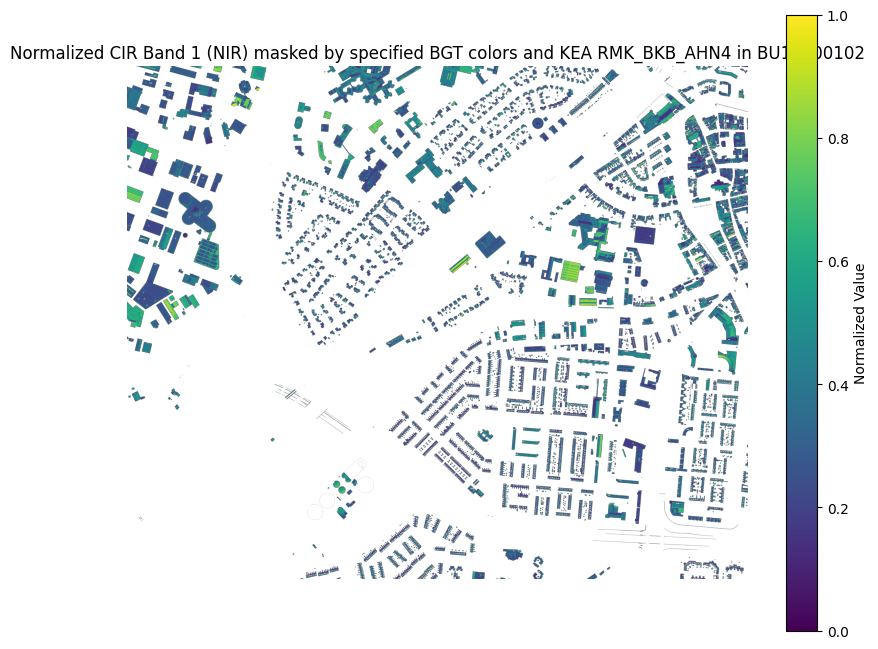

Normalized CIR map saved to: outdir/BU19000102_CIR_BGT_RedParts_normalized.tif
Sampling 100000 values from 9394723 valid pixels for Jenks breaks calculation...
Jenks natural breaks for 5 classes: [np.float32(0.03448276), np.float32(0.2413793), np.float32(0.34913793), np.float32(0.48706895), np.float32(0.6594828), np.float32(1.0)]


/tmp/ipykernel_6907/2487864997.py:309: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', num_classes)


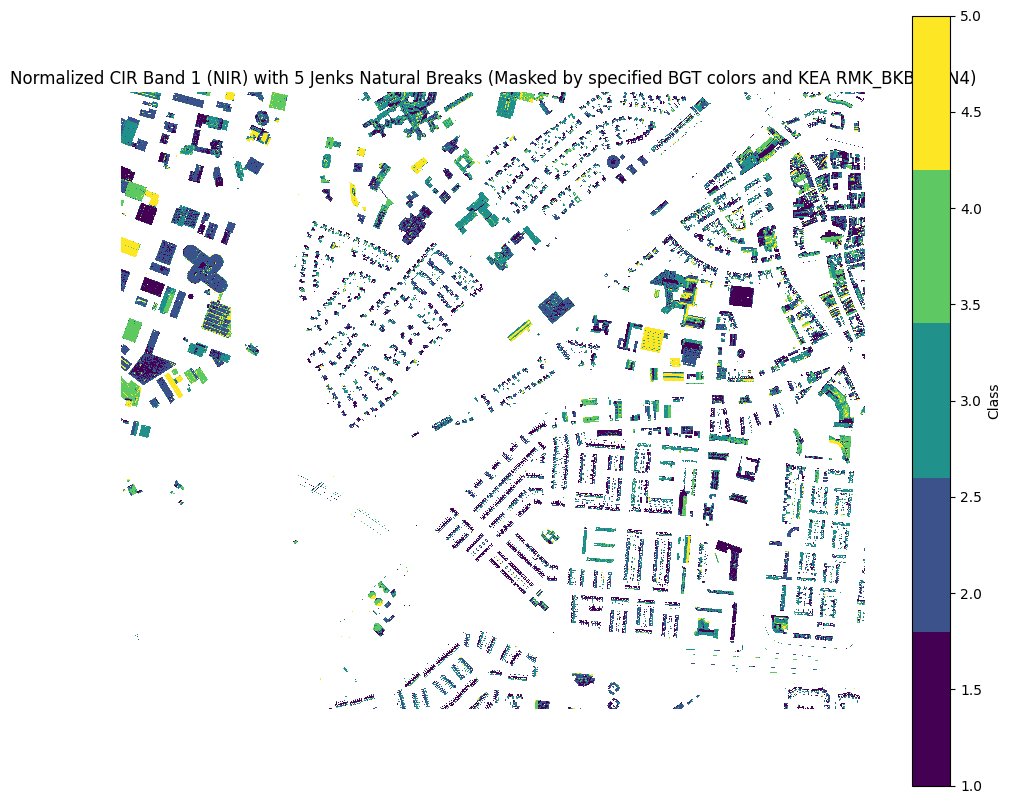

In [10]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
# import jenkspy # Moved into try-except block for installation

# Install jenkspy if not already installed
try:
    import jenkspy
except ImportError:
    print("jenkspy not found, installing...")
    !pip install jenkspy
    import jenkspy

# Ensure current working directory is 'Groenbeeld' for relative paths to work correctly
if os.path.basename(os.getcwd()) != 'Groenbeeld':
    print(f"Changing directory from {os.getcwd()} to /content/Groenbeeld")
    os.chdir('/content/Groenbeeld')
    print(f"Current working directory is now: {os.getcwd()}")
else:
    print(f"Current working directory already Groenbeeld: {os.getcwd()}")


# Assuming the current working directory is 'Groenbeeld'
base_output_dir = 'outdir/municipality_survey_V2'
target_id = 'BU19000102'
# Fix: The output files are directly in base_output_dir, not in a subfolder named target_id
neighborhood_dir = base_output_dir # Corrected line

print(f"Current working directory: {os.getcwd()}")
print(f"Checking for directory: {neighborhood_dir}")

# Diagnostic: List contents of 'outdir' to understand actual structure
print("\n--- Contents of 'outdir' (recursive) ---")
!ls -R outdir
print("--------------------------------------\n")

if os.path.exists(neighborhood_dir):
    for f in os.listdir(neighborhood_dir):
        # Diagnostic: Only print files if they match the expected pattern or are relevant
        if target_id in f or f.endswith(('.npy', '.tif')):
            print(f)
else:
    print(f"Directory not found: {neighborhood_dir}")
    raise FileNotFoundError(f"Required directory {neighborhood_dir} does not exist.")

# Determine the full neighborhood name for correct file paths
# From the `ls` output and previous script's logs, it appears the full name is 'BU19000102_Stationsbuurt'
neighborhood_full_name = f"{target_id}_Stationsbuurt"

# Define file paths for the CIR data (now from a TIFF) and the BGT layer
cir_data_path = os.path.join(neighborhood_dir, f"{neighborhood_full_name}_CIR.tif")
bgt_data_path = os.path.join(neighborhood_dir, f"{neighborhood_full_name}_BGT.tif") # Changed to BGT
geo_ref_path = os.path.join(neighborhood_dir, f"{neighborhood_full_name}_DSM.tif") # Use DSM for georeferencing
kea_rmk_bkb_data_path = os.path.join(neighborhood_dir, f"{neighborhood_full_name}_KEA_RMK_BKB_AHN4.tif") # New KEA layer path

# Check if all necessary files exist
if not os.path.exists(cir_data_path):
    raise FileNotFoundError(f"Error: CIR data file not found at {cir_data_path}")
if not os.path.exists(bgt_data_path):
    raise FileNotFoundError(f"Error: BGT layer file not found at {bgt_data_path}") # Changed path
if not os.path.exists(geo_ref_path):
    raise FileNotFoundError(f"Error: Georeference file not found at {geo_ref_path}")
if not os.path.exists(kea_rmk_bkb_data_path):
    raise FileNotFoundError(f"Error: KEA RMK_BKB_AHN4 file not found at {kea_rmk_bkb_data_path}")

# Load CIR array from .tif file using rasterio
cir_map = None
try:
    with rasterio.open(cir_data_path) as src_cir:
        # Assuming CIR is a multi-band image (e.g., NIR-Red-Green)
        # Read all bands. Rasterio reads bands as (count, height, width)
        cir_map = src_cir.read()
        print(f"Loaded CIR map from TIFF with shape: {cir_map.shape}")
except Exception as e:
    raise RuntimeError(f"Failed to load CIR data from {cir_data_path}: {e}")

# Load BGT layer (RGB for red detection)
bgt_profile = None
bgt_data = None
try:
    with rasterio.open(bgt_data_path) as src_bgt:
        bgt_data = src_bgt.read() # Read all bands (assuming RGB or RGBA)
        bgt_profile = src_bgt.profile
        print(f"Loaded BGT layer with shape: {bgt_data.shape}")
        print(f"BGT layer profile: {bgt_profile}")
except Exception as e:
    raise RuntimeError(f"Failed to load BGT layer from {bgt_data_path}: {e}")

# Load KEA RMK_BKB_AHN4 layer
kea_rmk_bkb_data = None
try:
    with rasterio.open(kea_rmk_bkb_data_path) as src_kea:
        kea_rmk_bkb_data = src_kea.read(1) # Assuming it's a single band
        print(f"Loaded KEA RMK_BKB_AHN4 layer with shape: {kea_rmk_bkb_data.shape}")
except Exception as e:
    raise RuntimeError(f"Failed to load KEA RMK_BKB_AHN4 layer from {kea_rmk_bkb_data_path}: {e}")

# Get georeferencing information from a reference GeoTIFF (e.g., DSM.tif)
geo_ref_profile = None
try:
    with rasterio.open(geo_ref_path) as src_ref:
        geo_ref_profile = src_ref.profile
        print(f"Georeference profile from {geo_ref_path}: {geo_ref_profile}")
except Exception as e:
    raise RuntimeError(f"Failed to load georeference data from {geo_ref_path}: {e}")

# Ensure all data is loaded and dimensions match
expected_height = geo_ref_profile['height']
expected_width = geo_ref_profile['width']

if cir_map.shape[1] != expected_height or cir_map.shape[2] != expected_width:
    raise ValueError(f"CIR map dimensions ({cir_map.shape[1]}, {cir_map.shape[2]}) "
                     f"do not match reference GeoTIFF dimensions ({expected_height}, {expected_width}).")

# Check BGT dimensions based on its band count
if bgt_data.ndim == 3: # Multi-band (e.g., RGB)
    if bgt_data.shape[1] != expected_height or bgt_data.shape[2] != expected_width:
        raise ValueError(f"BGT layer dimensions ({bgt_data.shape[1]}, {bgt_data.shape[2]}) do not match reference GeoTIFF dimensions ({expected_height}, {expected_width}).")
elif bgt_data.ndim == 2: # Single band
    if bgt_data.shape[0] != expected_height or bgt_data.shape[1] != expected_width:
        raise ValueError(f"BGT layer dimensions ({bgt_data.shape[0]}, {bgt_data.shape[1]}) do not match reference GeoTIFF dimensions ({expected_height}, {expected_width}).")
else:
    raise ValueError("Unexpected BGT data dimensions: {bgt_data.shape}")

# Check KEA dimensions
if kea_rmk_bkb_data.shape[0] != expected_height or kea_rmk_bkb_data.shape[1] != expected_width:
    raise ValueError(f"KEA RMK_BKB_AHN4 layer dimensions ({kea_rmk_bkb_data.shape[0]}, {kea_rmk_bkb_data.shape[1]}) do not match reference GeoTIFF dimensions ({expected_height}, {expected_width}).")

print("CIR map, BGT layer and KEA RMK_BKB_AHN4 layer dimensions are consistent with reference GeoTIFF.")

# Create an overlap mask from BGT data to find 'red parts' based on specific RGB values
if bgt_data.shape[0] >= 3: # Ensure it has at least 3 bands for RGB
    # Convert BGT data to (height, width, bands) for easier RGB comparison
    bgt_rgb_image = np.moveaxis(bgt_data, 0, -1) # Now (H, W, 3)

    # Define the target colors
    target_color1 = np.array([204, 0, 0], dtype=bgt_rgb_image.dtype)
    target_color2 = np.array([204, 0, 0], dtype=bgt_rgb_image.dtype)

    # Create a mask for each color by checking if all three channels match
    mask_color1 = np.all(bgt_rgb_image == target_color1, axis=-1)
    mask_color2 = np.all(bgt_rgb_image == target_color2, axis=-1)

    # Combine the masks using logical OR
    red_mask = mask_color1 | mask_color2

    print(f"Identified {np.sum(red_mask)} pixels matching colors [204,0,0] or [204,0,0] in the BGT map.")
elif bgt_data.shape[0] == 1: # Single band BGT, likely thematic. Need to guess what 'red' means.
    print("BGT is a single-band image. Cannot retrieve specific RGB colors.")
    red_mask = np.zeros(bgt_data.shape[1:], dtype=bool)
else:
    raise ValueError("BGT data does not appear to be a standard RGB or single-band image for color detection.")

# Create mask for colored pixels in KEA RMK_BKB_AHN4 layer
# Assuming colored means non-zero. Adjust this logic if 0 is a valid feature value and nodata is different.
kea_mask = (kea_rmk_bkb_data != 0) # Assuming 0 is background/no feature
print(f"Identified {np.sum(kea_mask)} non-zero pixels in the KEA RMK_BKB_AHN4 map.")

# Combine the BGT red_mask with the inverse of the KEA mask
overlap_mask = red_mask & ~kea_mask # Exclude areas from red_mask that are in kea_mask
print(f"Identified {np.sum(overlap_mask)} combined pixels from specified BGT colors and KEA non-zero pixels.")

# Free up memory from original BGT data and channels after mask is created
del bgt_data, kea_rmk_bkb_data

# Apply the mask to each band of the CIR map
masked_cir = np.empty_like(cir_map, dtype=np.float32) # Explicitly float32
for i in range(cir_map.shape[0]):
    band_data = cir_map[i, :, :].astype(np.float32) # Ensure float32 for calculations
    band_data[~overlap_mask] = np.nan # Set non-overlap regions to NaN
    masked_cir[i, :, :] = band_data

print(f"Masked CIR map shape: {masked_cir.shape}")

# Free up memory from original CIR map and overlap mask after masked_cir is created
del cir_map, overlap_mask

# Normalize CIR values within the overlap region (min-max normalization to 0-1)
normalized_masked_cir = np.empty_like(masked_cir, dtype=np.float32) # Explicitly float32

for i in range(normalized_masked_cir.shape[0]): # Changed loop range to normalized_masked_cir.shape[0]
    band_values = masked_cir[i, :, :]
    # Optimized: Use np.nanmin and np.nanmax to avoid creating a large 'valid_values' array
    min_val = np.nanmin(band_values) if not np.all(np.isnan(band_values)) else np.nan
    max_val = np.nanmax(band_values) if not np.all(np.isnan(band_values)) else np.nan

    if not np.isnan(min_val) and not np.isnan(max_val): # Check if any valid values exist
        if max_val - min_val > 0:
            normalized_band = (band_values - min_val) / (max_val - min_val)
            # Restore NaN for non-overlap regions
            normalized_band[np.isnan(band_values)] = np.nan
        else: # All valid values are the same in the overlap region
            normalized_band = np.full_like(band_values, np.nan, dtype=np.float32) # Explicitly float32
            normalized_band[~np.isnan(band_values)] = 0.5 # Set to mid-range if all values are constant
    else: # No valid values in this band for the overlap region
        normalized_band = np.full_like(band_values, np.nan, dtype=np.float32) # Explicitly float32

    normalized_masked_cir[i, :, :] = normalized_band

print(f"Normalized masked CIR map shape: {normalized_masked_cir.shape}")
print("Normalization complete. Values in overlap region are scaled between 0 and 1 (or NaN elsewhere).")

# Free up memory from masked_cir after normalized_masked_cir is created
del masked_cir

# Visualize a band of the normalized CIR map (e.g., the first band)
plt.figure(figsize=(10, 8))
plt.imshow(normalized_masked_cir[0, :, :], cmap='viridis', vmin=0, vmax=1)
plt.title(f"Normalized CIR Band 1 (NIR) masked by specified BGT colors and KEA RMK_BKB_AHN4 in {target_id}")
plt.colorbar(label="Normalized Value")
plt.axis('off')
plt.show()
plt.close('all') # Close the plot to free up resources

# Save the normalized CIR map as a GeoTIFF
output_profile = geo_ref_profile.copy()
output_profile.update({
    'dtype': rasterio.float32,
    'count': normalized_masked_cir.shape[0], # Number of bands in CIR
    'nodata': np.nan # Use NaN as nodata value
})

# Define the user-specified output directory
user_output_dir = 'outdir'

# Create the output directory if it doesn't exist
os.makedirs(user_output_dir, exist_ok=True)

output_path = os.path.join(user_output_dir, f"{target_id}_CIR_BGT_RedParts_normalized.tif")
try:
    with rasterio.open(output_path, 'w', **output_profile) as dst:
        for i in range(normalized_masked_cir.shape[0]):
            dst.write(normalized_masked_cir[i].astype(rasterio.float32), i + 1)
    print(f"Normalized CIR map saved to: {output_path}")
except Exception as e:
    print(f"Error saving normalized CIR map: {e}")


# --- Jenks Natural Breaks Calculation and Visualization ---
# Define the number of classes for natural breaks
num_classes = 5 # You might want to experiment with this number (e.g., 3, 5, 7)

# --- Optimization for large datasets: Sample the data for Jenks breaks calculation ---
# Jenks breaks can be slow on very large arrays. Sampling can significantly reduce runtime.
sample_size = 100000 # Define a suitable sample size

# Optimized: Identify valid pixel indices once, then sample from these indices
valid_pixel_mask = ~np.isnan(normalized_masked_cir[0, :, :])
valid_pixel_indices_row, valid_pixel_indices_col = np.where(valid_pixel_mask) # Returns tuple of (rows, cols)

num_valid_pixels = len(valid_pixel_indices_row)

if num_valid_pixels > sample_size:
    # Take a random sample of indices if the dataset is larger than the sample_size
    np.random.seed(42) # For reproducibility
    # Create a combined index array for easier sampling from the valid pixel list
    all_indices_in_valid_list = np.arange(num_valid_pixels)
    sampled_indices_in_valid_list = np.random.choice(all_indices_in_valid_list, size=sample_size, replace=False)

    # Map sampled indices back to original 2D coordinates and extract values
    sampled_values = normalized_masked_cir[0, valid_pixel_indices_row[sampled_indices_in_valid_list], \
                                           valid_pixel_indices_col[sampled_indices_in_valid_list]]
    print(f"Sampling {sample_size} values from {num_valid_pixels} valid pixels for Jenks breaks calculation...")
else:
    # If not large enough for sampling, then extract all valid values
    sampled_values = normalized_masked_cir[0, valid_pixel_indices_row, valid_pixel_indices_col]
    print("Dataset size is smaller than or equal to sample_size, using all valid values for Jenks breaks.")

# Free up intermediate index arrays after sampling
del valid_pixel_mask, valid_pixel_indices_row, valid_pixel_indices_col


# Calculate Jenks natural breaks
# Ensure there are enough unique values for the requested number of classes
if len(np.unique(sampled_values)) >= num_classes:
    breaks = jenkspy.jenks_breaks(sampled_values, n_classes=num_classes)
    print(f"Jenks natural breaks for {num_classes} classes: {breaks}")

    # Visualize the data using these natural breaks
    plt.figure(figsize=(12, 10))

    # Let's keep `normalized_masked_cir` until after the categorized map is created and plotted.

    # For simplicity, let's create a categorized map based on breaks
    categorized_map = np.zeros_like(normalized_masked_cir[0, :, :], dtype=np.int8) # Explicitly int8
    # Initialize with NaN where CIR is NaN, so these regions don't get a category
    categorized_map[np.isnan(normalized_masked_cir[0, :, :])] = -1 # Use -1 to indicate no data/masked areas

    for i in range(num_classes):
        lower_bound = breaks[i]
        upper_bound = breaks[i+1]
        # Assign a category index to values falling within each break
        # Ensure to only assign where original data is not NaN
        if i == num_classes - 1: # Last class, upper bound is inclusive
            categorized_map[(normalized_masked_cir[0, :, :] >= lower_bound) &
                            (normalized_masked_cir[0, :, :] <= upper_bound) &
                            (~np.isnan(normalized_masked_cir[0, :, :]))] = i + 1
        else:
            categorized_map[(normalized_masked_cir[0, :, :] >= lower_bound) &
                            (normalized_masked_cir[0, :, :] < upper_bound) &
                            (~np.isnan(normalized_masked_cir[0, :, :]))] = i + 1

    # Mask the -1 values for plotting, so they appear as background or transparent
    categorized_map_masked = np.ma.masked_where(categorized_map == -1, categorized_map)

    # Plot the categorized map
    # Using a discrete colormap for categories
    cmap = plt.cm.get_cmap('viridis', num_classes)
    plt.imshow(categorized_map_masked, cmap=cmap, interpolation='nearest', vmin=1, vmax=num_classes)
    plt.title(f"Normalized CIR Band 1 (NIR) with {num_classes} Jenks Natural Breaks (Masked by specified BGT colors and KEA RMK_BKB_AHN4)")
    plt.colorbar(label="Class")
    plt.axis('off')
    plt.show()
    plt.close('all') # Close the plot to free up resources

    # Free up memory from normalized_masked_cir after all visualizations that use it are complete
    del normalized_masked_cir

else:
    print(f"Not enough unique values ({len(np.unique(sampled_values))}) in the sampled data to calculate {num_classes} Jenks breaks. Skipping visualization.")

In [11]:
output_classified_path = os.path.join(user_output_dir, f"{target_id}_CIR_BGT_RedParts_classified.tif")

# Create a new profile for the classified output, based on the georeference profile
classified_profile = geo_ref_profile.copy()
classified_profile.update({
    'dtype': rasterio.int8, # Use int8 as categories are small integers
    'count': 1, # Single band for classified data
    'nodata': -1 # Use -1 as nodata value for categorized_map
})

try:
    with rasterio.open(output_classified_path, 'w', **classified_profile) as dst:
        # Write the categorized map, ensuring it's cast to the correct dtype and includes the nodata values
        dst.write(categorized_map.astype(rasterio.int8), 1)
    print(f"Classified map saved to: {output_classified_path}")
except Exception as e:
    print(f"Error saving classified map: {e}")

# Upload both maps
from google.colab import files

print(f"Downloading {output_path}")
files.download(output_path)

print(f"Downloading {output_classified_path}")
files.download(output_classified_path)

Classified map saved to: outdir/BU19000102_CIR_BGT_RedParts_classified.tif


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>